# **Credit Card Fraud Detection**

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

## Load Dataset

In [2]:
df = pd.read_csv("Synthetic_Financial_datasets_log.csv")

## Dataset Overview

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [4]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [5]:
print(df.shape)

df.info()

df.describe()

(614230, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614230 entries, 0 to 614229
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            614230 non-null  int64  
 1   type            614230 non-null  object 
 2   amount          614230 non-null  float64
 3   nameOrig        614230 non-null  object 
 4   oldbalanceOrg   614229 non-null  float64
 5   newbalanceOrig  614229 non-null  float64
 6   nameDest        614229 non-null  object 
 7   oldbalanceDest  614229 non-null  float64
 8   newbalanceDest  614229 non-null  float64
 9   isFraud         614229 non-null  float64
 10  isFlaggedFraud  614229 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 51.5+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,614230.000000,6.142300e+05,6.142290e+05,6.142290e+05,6.142290e+05,6.142290e+05,614229.000000,614229.0
mean,16.006042,1.614285e+05,8.858924e+05,9.058131e+05,9.735209e+05,1.136259e+06,0.000604,0.0
std,6.085964,2.695323e+05,2.947824e+06,2.984931e+06,2.317154e+06,2.473791e+06,0.024569,0.0
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,12.000000,1.237187e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,16.000000,7.572355e+04,1.782000e+04,0.000000e+00,1.127733e+05,2.061590e+05,0.000000,0.0
75%,19.000000,2.154661e+05,1.562265e+05,1.955262e+05,8.900892e+05,1.168700e+06,0.000000,0.0
max,34.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.148270e+07,4.148270e+07,1.000000,0.0


## Data Preprocessing and EDA

In [6]:
df.dropna(inplace=True)

print(df.shape)

(614229, 11)


In [7]:
print(df['isFraud'].value_counts())

print("\nPercentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)

isFraud
0.0    613858
1.0       371
Name: count, dtype: int64

Percentage:
isFraud
0.0    99.939599
1.0     0.060401
Name: proportion, dtype: float64


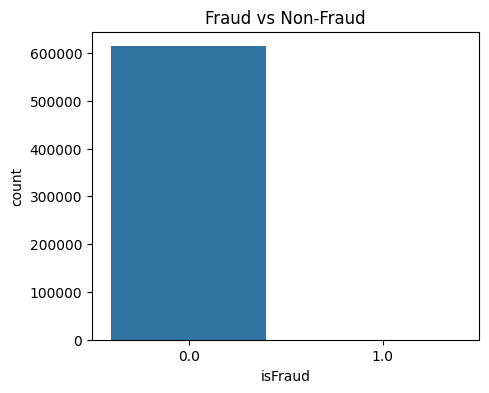

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x='isFraud', data=df)

plt.title("Fraud vs Non-Fraud")
plt.show()

## Feature Selection and Engineering

In [9]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X = X.drop(['nameOrig', 'nameDest'], axis=1)

X = pd.get_dummies(X, columns=['type'], drop_first=True)

## Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Baseline Models**

## Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

lr_base = LogisticRegression(max_iter=1000)
lr_base.fit(X_train, y_train)

y_pred_base_lr = lr_base.predict(X_test)

## Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)

y_pred_base_rf = rf_base.predict(X_test)

## XGBoost

In [13]:
!pip install xgboost

In [14]:
from xgboost import XGBClassifier

xgb_base = XGBClassifier(eval_metric='logloss')
xgb_base.fit(X_train, y_train)

y_pred_base_xgb = xgb_base.predict(X_test)

# Comparing Baseline Models

In [15]:
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base_lr),
        accuracy_score(y_test, y_pred_base_rf),
        accuracy_score(y_test, y_pred_base_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_base_lr),
        precision_score(y_test, y_pred_base_rf),
        precision_score(y_test, y_pred_base_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_base_lr),
        recall_score(y_test, y_pred_base_rf),
        recall_score(y_test, y_pred_base_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_base_lr),
        f1_score(y_test, y_pred_base_rf),
        f1_score(y_test, y_pred_base_xgb)
    ]
})

baseline_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.999495,0.833333,0.202703,0.326087
1,Random Forest,0.999780,0.979592,0.648649,0.780488
2,XGBoost,0.999821,0.933333,0.756757,0.835821


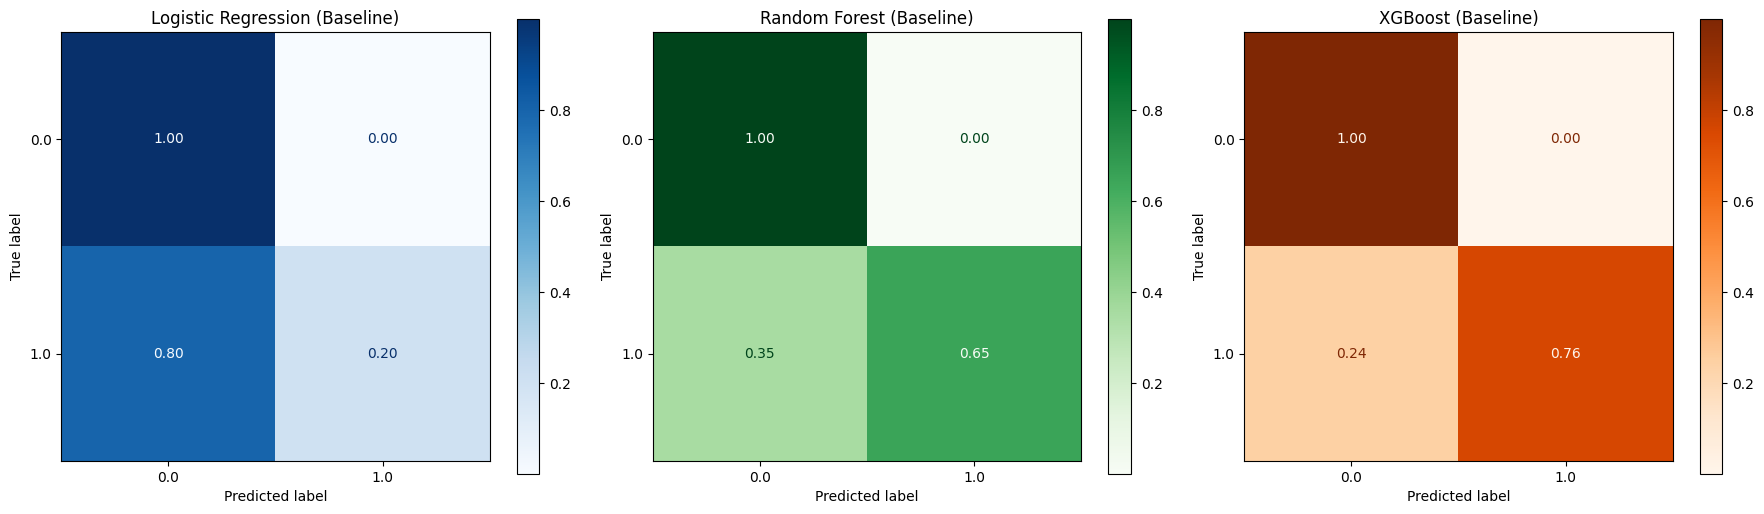

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_base_lr,
    normalize='true',
    values_format='.2f',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Logistic Regression (Baseline)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_base_rf,
    normalize='true',
    values_format='.2f',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title("Random Forest (Baseline)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_base_xgb,
    normalize='true',
    values_format='.2f',
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title("XGBoost (Baseline)")

plt.tight_layout()
plt.show()

# **Handling Class Imbalance using Class Weights**

## Logistic Regression (Weighted)

In [17]:
from sklearn.linear_model import LogisticRegression

lr_w = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr_w.fit(X_train, y_train)
y_pred_w_lr = lr_w.predict(X_test)

## Random Forest (Weighted)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_w = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_w.fit(X_train, y_train)
y_pred_w_rf = rf_w.predict(X_test)

## XGBoost (Weighted)

In [19]:
from xgboost import XGBClassifier

xgb_w = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

xgb_w.fit(X_train, y_train)
y_pred_w_xgb = xgb_w.predict(X_test)

## Comparison

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

cw_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_w_lr),
        accuracy_score(y_test, y_pred_w_rf),
        accuracy_score(y_test, y_pred_w_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_w_lr),
        precision_score(y_test, y_pred_w_rf),
        precision_score(y_test, y_pred_w_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_w_lr),
        recall_score(y_test, y_pred_w_rf),
        recall_score(y_test, y_pred_w_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_w_lr),
        f1_score(y_test, y_pred_w_rf),
        f1_score(y_test, y_pred_w_xgb)
    ]
})

cw_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.899769,0.005814,0.972973,0.011560
1,Random Forest,0.999772,0.979167,0.635135,0.770492
2,XGBoost,0.999658,0.677778,0.824324,0.743902


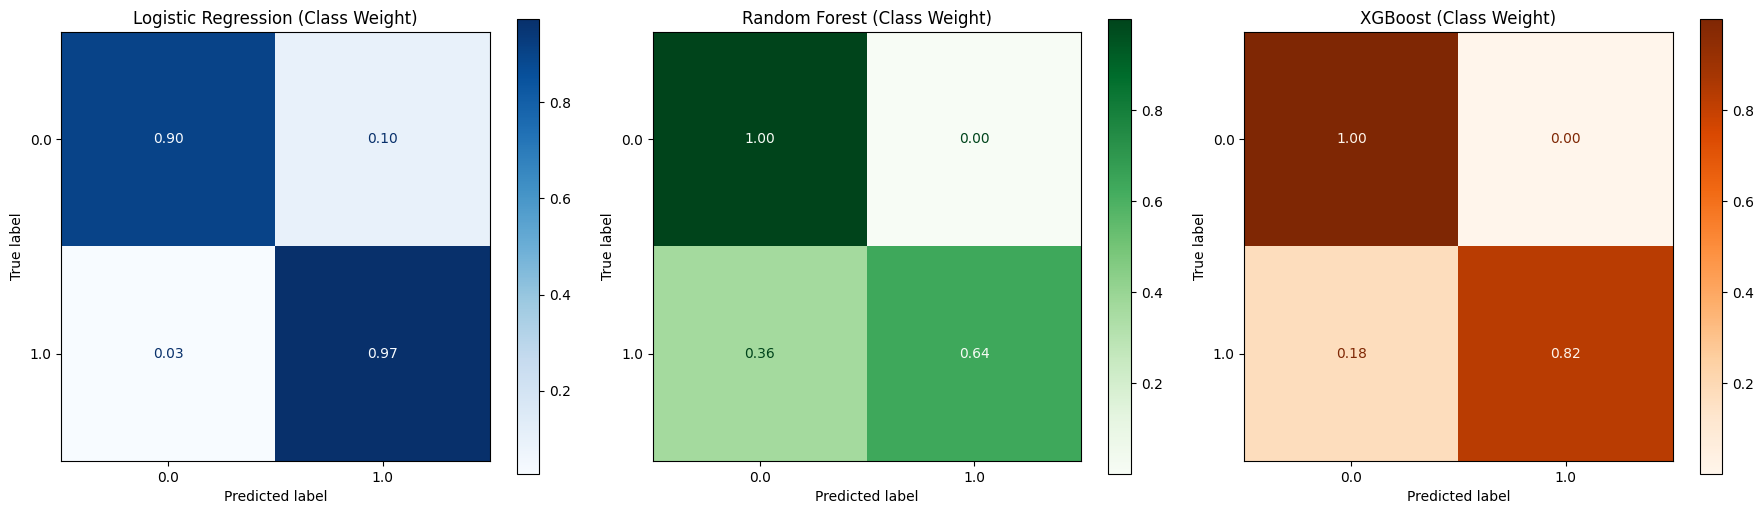

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_w_lr,
    normalize='true',
    values_format='.2f',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Logistic Regression (Class Weight)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_w_rf,
    normalize='true',
    values_format='.2f',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title("Random Forest (Class Weight)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_w_xgb,
    normalize='true',
    values_format='.2f',
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title("XGBoost (Class Weight)")

plt.tight_layout()
plt.show()

# **Handling Class Imbalance using SMOTE**

In [22]:
!pip install imbalanced-learn

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [24]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
isFraud
0.0    491086
1.0       297
Name: count, dtype: int64

After SMOTE:
isFraud
0.0    491086
1.0    491086
Name: count, dtype: int64


## Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote_lr = lr_smote.predict(X_test)

## Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote_rf = rf_smote.predict(X_test)

In [27]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_smote.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
2,oldbalanceOrg,0.248474
3,newbalanceOrig,0.173722
10,type_TRANSFER,0.116350
1,amount,0.116107
5,newbalanceDest,0.081451
9,type_PAYMENT,0.072922
4,oldbalanceDest,0.072410
7,type_CASH_OUT,0.062696
0,step,0.055551
8,type_DEBIT,0.000315


## XGBoost

In [28]:
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_smote_xgb = xgb_smote.predict(X_test)

In [29]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_smote.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance.head(10)

,Feature,Importance
3,newbalanceOrig,0.444764
9,type_PAYMENT,0.303851
2,oldbalanceOrg,0.100418
1,amount,0.051593
10,type_TRANSFER,0.024759
8,type_DEBIT,0.019824
7,type_CASH_OUT,0.016847
0,step,0.014826
4,oldbalanceDest,0.012551
5,newbalanceDest,0.010567


## Model Comparison

In [30]:
from sklearn.metrics import roc_auc_score

roc_auc_lr = roc_auc_score(y_test, lr_smote.predict_proba(X_test)[:,1])
roc_auc_rf = roc_auc_score(y_test, rf_smote.predict_proba(X_test)[:,1])
roc_auc_xgb = roc_auc_score(y_test, xgb_smote.predict_proba(X_test)[:,1])

In [31]:
final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_smote_lr),
        accuracy_score(y_test, y_pred_smote_rf),
        accuracy_score(y_test, y_pred_smote_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_smote_lr),
        precision_score(y_test, y_pred_smote_rf),
        precision_score(y_test,y_pred_smote_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_smote_lr),
        recall_score(y_test, y_pred_smote_rf),
        recall_score(y_test, y_pred_smote_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_smote_lr),
        f1_score(y_test, y_pred_smote_rf),
        f1_score(y_test, y_pred_smote_xgb)
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9137,0.0067,0.9595,0.0132,0.9824
1,Random Forest,0.9989,0.3410,0.7973,0.4777,0.9913
2,XGBoost,0.9936,0.0815,0.9324,0.1498,0.9971


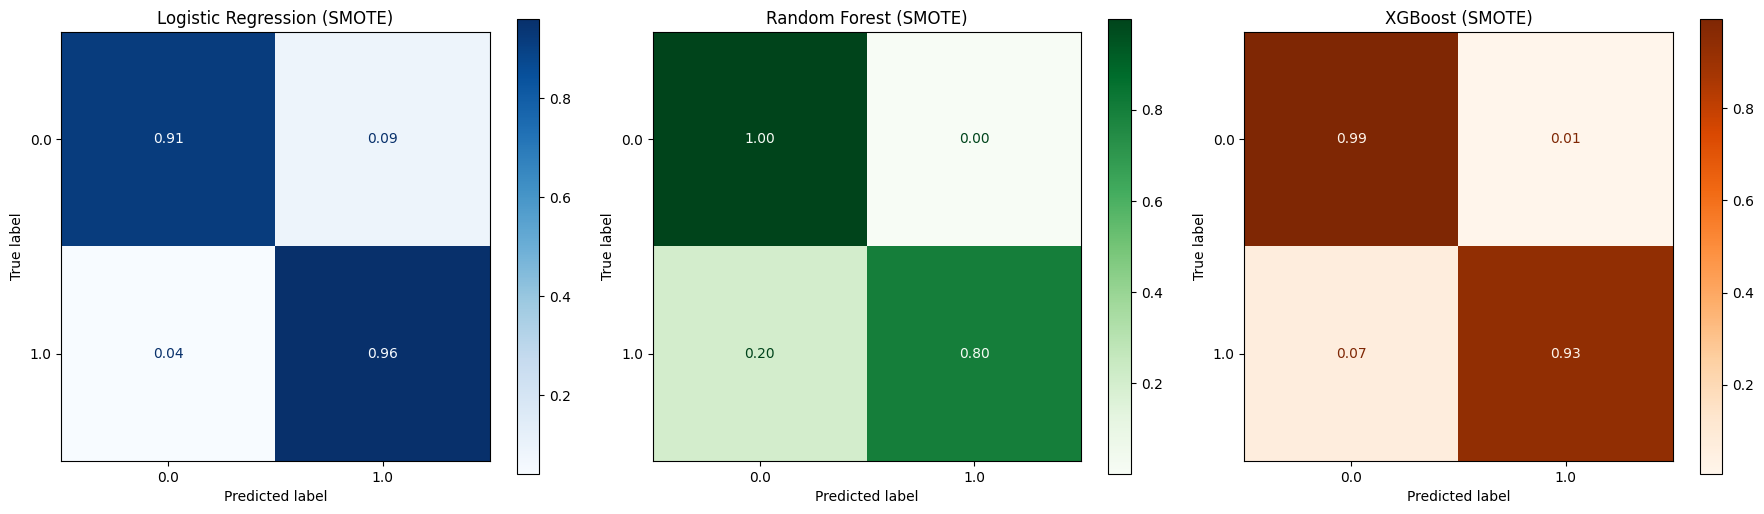

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote_lr,
    normalize='true',
    values_format='.2f',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Logistic Regression (SMOTE)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote_rf,
    normalize='true',
    values_format='.2f',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title("Random Forest (SMOTE)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote_xgb,
    normalize='true',
    values_format='.2f',
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title("XGBoost (SMOTE)")

plt.tight_layout()
plt.show()

# **Handling Class Imbalance using SMOTE-Tomek**

In [33]:
from imblearn.combine import SMOTETomek

smk = SMOTETomek(random_state=42)

X_train_smk, y_train_smk = smk.fit_resample(X_train, y_train)

## Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

lr_smk = LogisticRegression(max_iter=1000)
lr_smk.fit(X_train_smk, y_train_smk)

y_pred_smk_lr = lr_smk.predict(X_test)

## Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_smk = RandomForestClassifier(random_state=42)
rf_smk.fit(X_train_smk, y_train_smk)

y_pred_smk_rf = rf_smk.predict(X_test)

## XGBoost

In [36]:
from xgboost import XGBClassifier

xgb_smk = XGBClassifier(eval_metric='logloss')
xgb_smk.fit(X_train_smk, y_train_smk)

y_pred_smk_xgb = xgb_smk.predict(X_test)

## Comparing

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

smk_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_smk_lr),
        accuracy_score(y_test, y_pred_smk_rf),
        accuracy_score(y_test, y_pred_smk_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_smk_lr),
        precision_score(y_test, y_pred_smk_rf),
        precision_score(y_test, y_pred_smk_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_smk_lr),
        recall_score(y_test, y_pred_smk_rf),
        recall_score(y_test, y_pred_smk_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_smk_lr),
        f1_score(y_test, y_pred_smk_rf),
        f1_score(y_test, y_pred_smk_xgb)
    ]
})

smk_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.913876,0.006668,0.959459,0.013244
1,Random Forest,0.998991,0.351190,0.797297,0.487603
2,XGBoost,0.995791,0.113438,0.878378,0.200927


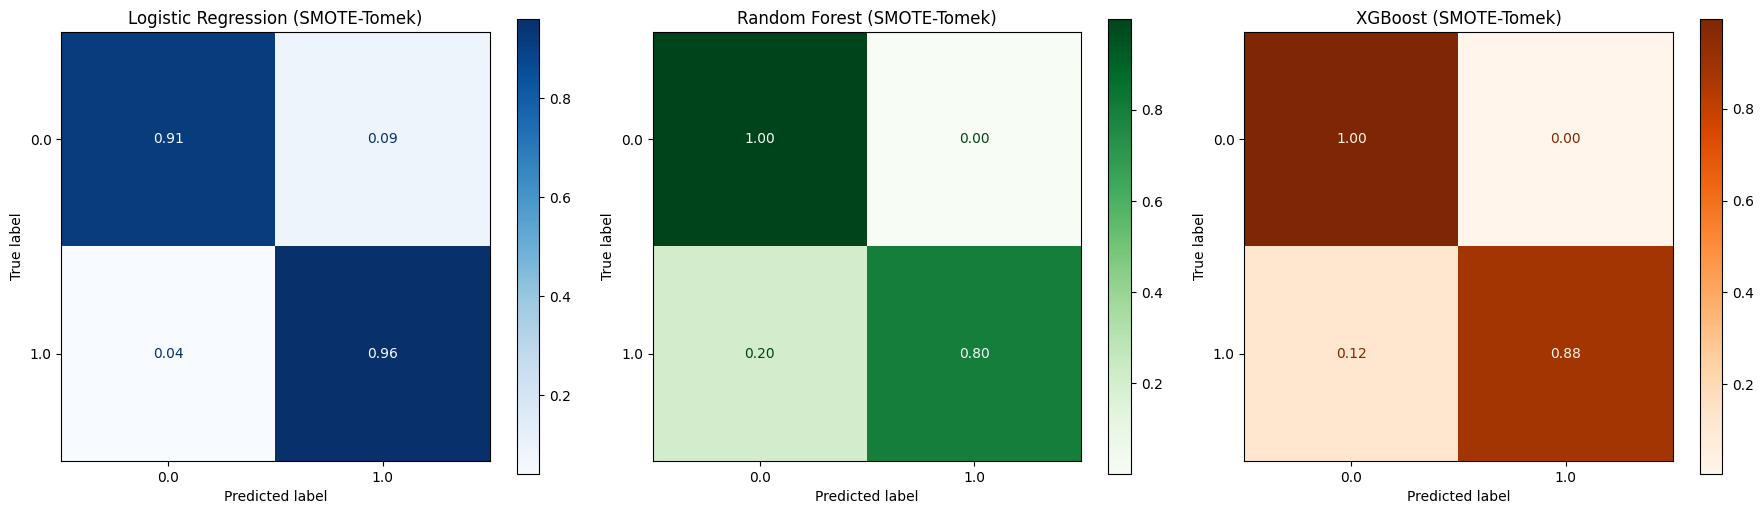

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smk_lr,
    normalize='true',
    values_format='.2f',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Logistic Regression (SMOTE-Tomek)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smk_rf,
    normalize='true',
    values_format='.2f',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title("Random Forest (SMOTE-Tomek)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smk_xgb,
    normalize='true',
    values_format='.2f',
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title("XGBoost (SMOTE-Tomek)")

plt.tight_layout()
plt.show()

In [39]:
results = []

def add_result(model, method, y_true, y_pred):
    results.append({
        "Model": model,
        "Method": method,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    })

# ---------------- BASELINE ----------------
add_result("Logistic Regression", "Baseline", y_test, y_pred_base_lr)
add_result("Random Forest", "Baseline", y_test, y_pred_base_rf)
add_result("XGBoost", "Baseline", y_test, y_pred_base_xgb)

# ---------------- SMOTE ----------------
add_result("Logistic Regression", "SMOTE", y_test, y_pred_smote_lr)
add_result("Random Forest", "SMOTE", y_test, y_pred_smote_rf)
add_result("XGBoost", "SMOTE", y_test, y_pred_smote_xgb)

# ---------------- SMOTE-TOMEK ----------------
add_result("Logistic Regression", "SMOTE-Tomek", y_test, y_pred_smk_lr)
add_result("Random Forest", "SMOTE-Tomek", y_test, y_pred_smk_rf)
add_result("XGBoost", "SMOTE-Tomek", y_test, y_pred_smk_xgb)

# ---------------- CLASS WEIGHT ----------------
add_result("Logistic Regression", "Class Weight", y_test, y_pred_w_lr)
add_result("Random Forest", "Class Weight", y_test, y_pred_w_rf)
add_result("XGBoost", "Class Weight", y_test, y_pred_w_xgb)

# FINAL DATAFRAME
df_results = pd.DataFrame(results)


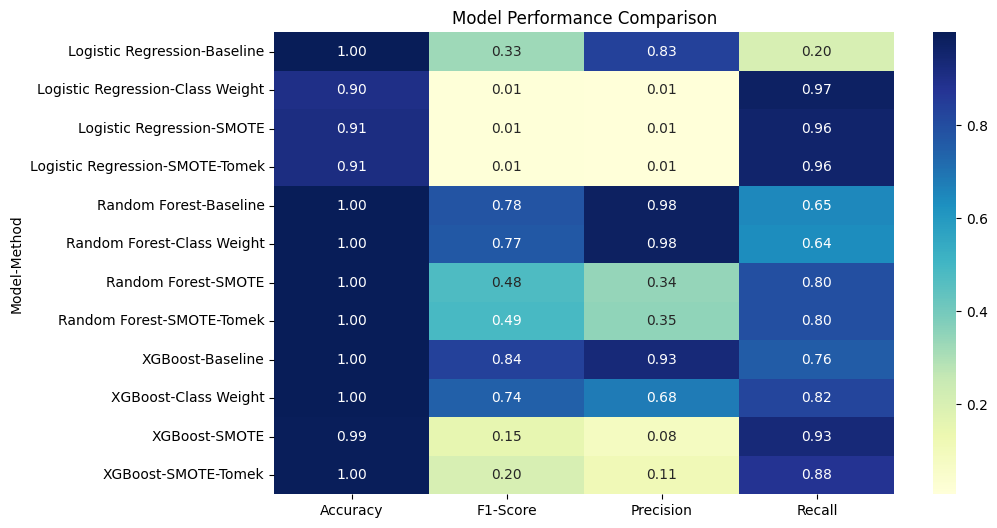

In [40]:
df_plot = df_results.copy()

df_pivot = df_plot.pivot_table(
    index=["Model", "Method"],
    values=["Accuracy", "Precision", "Recall", "F1-Score"]
)

# Plot
plt.figure(figsize=(10,6))
sns.heatmap(df_pivot, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("Model Performance Comparison")
plt.show()

## **Conclusion**

### XGBoost outperformed Logistic Regression and Random Forest across all experiments for fraud detection. While the baseline XGBoost model achieved the best balance with the highest F1-score (0.74) and precision (0.93), the SMOTE/SMOTE-Tomek versions achieved the highest recall (0.81), making them better at detecting more fraud cases.

### Overall, XGBoost is the most robust model, and the final choice depends on whether the priority is balanced performance (baseline) or maximum fraud detection (SMOTE variants).